In [1]:
from collections.abc import Callable
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr

# from context_flux_no.models.fluxfno import FluxFNO1D
from context_flux_no.nn.operators.fourier_utils import append_grid_channels
from context_flux_no.training import PDEDataset, SegmentLoader
from einops import rearrange
from jaxtyping import Array, Float, PRNGKeyArray, PyTree


# jax.config.update("jax_enable_x64", True)

datadir = Path("../../data")


In [2]:
dataset_xr = xr.load_dataset(datadir / "burgers_train.hdf5", engine="h5netcdf")
dataset_xr

<xarray.Dataset> Size: 51MB
Dimensions:  (pde: 50, ic: 1, t: 501, dim: 1, x: 256, param: 1)
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * param    (param) <U2 8B 'nu'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 51MB 0.08833 0.09131 ... 0.4381 0.4518
    coeffs   (pde, param) float64 400B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [3]:
dataset = PDEDataset.from_xarray(dataset_xr.sel(t=slice(None, None, 10)))

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)


In [4]:
test_arr = jnp.reshape(jnp.arange(10.0), (1, -1))
print(test_arr.shape)
stencil_size = (2, 2)
test_padded = jnp.pad(test_arr, pad_width=[(0, 0), stencil_size], mode="wrap")
print(test_padded.shape)

(1, 10)
(1, 14)


In [5]:
jax.lax.conv_general_dilated_patches(
    jnp.expand_dims(test_padded, axis=0), (sum(stencil_size) + 1,), (1,), "valid"
).shape

(1, 5, 10)

In [22]:
class FluxNO1D(eqx.Module):
    in_channels: int = eqx.field(static=True)
    stencil_widths: tuple[int, int] = eqx.field(static=True)
    lift_dim: int = eqx.field(static=True)
    hidden_dim: int = eqx.field(static=True)
    depth: int = eqx.field(static=True)

    lift_layer: eqx.nn.Conv1d
    mlp: eqx.nn.MLP

    def __init__(
        self,
        in_channels: int,
        stencil_widths: tuple[int, int],
        lift_dim: int,
        hidden_dim: int,
        depth: int,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        keys = jax.random.split(key, 2)
        kernel_size = stencil_widths[0] + stencil_widths[1] + 1
        self.lift_layer = eqx.nn.Conv1d(
            in_channels=in_channels + 1,
            out_channels=lift_dim,
            kernel_size=kernel_size,
            dtype=dtype,
            key=keys[0],
        )
        self.mlp = eqx.nn.MLP(
            in_size=lift_dim,
            out_size=in_channels,
            width_size=hidden_dim,
            depth=depth,
            activation=jax.nn.gelu,
            dtype=dtype,
            key=keys[1],
        )
        self.in_channels = in_channels
        self.stencil_widths = stencil_widths
        self.lift_dim = lift_dim
        self.hidden_dim = hidden_dim
        self.depth = depth

    @property
    def stencil_size(self) -> int:
        return sum(self.stencil_widths) + 1

    def get_stencils(
        self, u: Float[Array, "channels grid_x"]
    ) -> Float[Array, "lift_dim grids_x+1"]:
        a, b = self.stencil_widths
        pad_widths = [(0, 0), (a + 1, b)]
        # Need to change mode if not periodic boundary condition
        u_padded = jnp.pad(u, pad_widths, mode="wrap")
        u_stencils = jax.lax.conv_general_dilated_patches(
            jnp.expand_dims(u_padded, axis=0),  # Requires a dummy batch axis
            filter_shape=(self.stencil_size,),
            window_strides=(1,),
            padding="valid",
        )[0]  # Remove the batch axis
        return rearrange(u_stencils, "(c s) ... -> c s ...", c=u.shape[0])

    def compute_flux(
        self, u_stencils: Float[Array, "channels {self.stencil_size} grids_x+1"]
    ) -> Float[Array, "channels grids_x+1"]:
        pass

    def __call__(
        self,
        u: Float[Array, "channels grids_x"],
        dt: float,
        dx: float,
        *,
        key: PRNGKeyArray | None = None,
    ) -> Float[Array, "channels grids_x"]:
        a, b = self.stencil_widths
        pad_widths = [(0, 0), (a + 1, b)]
        # Need to change mode if not periodic boundary condition
        u_padded = jnp.pad(append_grid_channels(u), pad_widths, mode="wrap")
        u_stencils: Float[Array, "lift_dim grids_x+1"] = self.lift_layer(u_padded)
        f: Float[Array, "channels grids_x+1"] = eqx.filter_vmap(
            self.mlp, in_axes=-1, out_axes=-1
        )(u_stencils)
        du_dt: Float[Array, "channels grids_x"] = -jnp.diff(f, axis=1) / dx
        return u + du_dt * dt

In [30]:
def train(
    model: eqx.Module,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn: Callable[[eqx.Module, PyTree[Array]], Float[Array, ""]],
    max_steps: int,
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_):
        batch, loader_state_ = dataloader.load_batch(loader_state_)

        (loss, aux), grads = loss_grad_fn(model_, batch)
        updates, opt_state_ = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_, opt_state_

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    loss_history = []
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state = train_step(
            model, loader_state, opt_state
        )
        ## Logging and save logic
        loss_ = loss.item()
        print(f"Step: {i}: loss = {loss_}")
        loss_history.append(loss_)
    return model, jnp.asarray(loss_history)

In [10]:
loader = SegmentLoader(dataset, 2, 1024)

In [11]:
loader_state = loader.init()
batch, loader_state = loader.load_batch(loader_state)

In [12]:
batch

(Array([[[[-1.2221556 , -1.2009941 , -1.1797621 , ..., -1.2851588 ,
           -1.2642441 , -1.2432408 ]],
 
         [[-1.1962246 , -1.1754305 , -1.154576  , ..., -1.2581959 ,
           -1.2376125 , -1.2169535 ]]],
 
 
        [[[-1.722522  , -1.7280893 , -1.7278968 , ..., -0.1065006 ,
           -0.53091973, -1.5410649 ]],
 
         [[-1.7273413 , -1.7252448 , -1.714551  , ..., -0.4752881 ,
           -1.4960892 , -1.7202096 ]]],
 
 
        [[[-1.8631605 , -1.8557026 , -1.8480359 , ..., -1.8845426 ,
           -1.8775531 , -1.8704351 ]],
 
         [[-1.8488668 , -1.8410575 , -1.8330032 , ..., -1.8710412 ,
           -1.8638349 , -1.8564516 ]]],
 
 
        ...,
 
 
        [[[-0.7168503 , -0.7122285 , -0.7067563 , ..., -0.7209636 ,
           -0.7209427 , -0.7199402 ]],
 
         [[-0.71361303, -0.7083477 , -0.70231557, ..., -0.72093517,
           -0.7203828 , -0.7179044 ]]],
 
 
        [[[ 0.45343307,  0.47820142,  0.50422657, ...,  0.38779444,
            0.40814885,  0.4300

In [35]:
model = FluxNO1D(
    in_channels=1,
    lift_dim=64,
    hidden_dim=64,
    depth=4,
    stencil_widths=(8, 8),
    key=jax.random.key(0),
)

In [36]:
from typing import Any


def mean_squared_error(model, batch) -> tuple[Float[Array, ""], Any]:
    u_batch, dt, dx = batch
    u0, u1 = u_batch[:, 0], u_batch[:, 1]
    u1_pred: Float[Array, "batch dim x"] = eqx.filter_vmap(
        model, in_axes=(0, None, None)
    )(u0, dt, dx)
    return jnp.mean((u1_pred - u1) ** 2), None


In [37]:
u_batch[0, 0].shape

(1, 256)

In [38]:
u_batch, dt, dx = batch
model(u_batch[0, 0], dt, dx).shape

(1, 256)

In [39]:
u_batch[:, 0].shape

(1024, 1, 256)

In [40]:
dx

np.float64(0.00390625)

In [41]:
mean_squared_error(model, batch)

(Array(0.00551667, dtype=float32), None)

In [42]:
model_trained, loss_history = train(
    model, loader, optax.adabelief(1e-3), mean_squared_error, max_steps=2000
)

Step: 0: loss = 0.00551666971296072
Step: 1: loss = 0.005014319438487291
Step: 2: loss = 0.005287719890475273
Step: 3: loss = 0.005741434171795845
Step: 4: loss = 0.005417680833488703
Step: 5: loss = 0.004925359971821308
Step: 6: loss = 0.0051987431943416595
Step: 7: loss = 0.004906852263957262
Step: 8: loss = 0.005048488266766071
Step: 9: loss = 0.00494166137650609
Step: 10: loss = 0.0049647679552435875
Step: 11: loss = 0.005108173005282879
Step: 12: loss = 0.004496855195611715
Step: 13: loss = 0.004313840065151453
Step: 14: loss = 0.004418063443154097
Step: 15: loss = 0.004381069913506508
Step: 16: loss = 0.003986234311014414
Step: 17: loss = 0.003498265752568841
Step: 18: loss = 0.0032892879098653793
Step: 19: loss = 0.0031239306554198265
Step: 20: loss = 0.0030653777066618204
Step: 21: loss = 0.0023197056725621223
Step: 22: loss = 0.001819671131670475
Step: 23: loss = 0.0015278853243216872
Step: 24: loss = 0.0012759505771100521
Step: 25: loss = 0.0011173500679433346
Step: 26: loss 

Text(0, 0.5, 'Train loss')

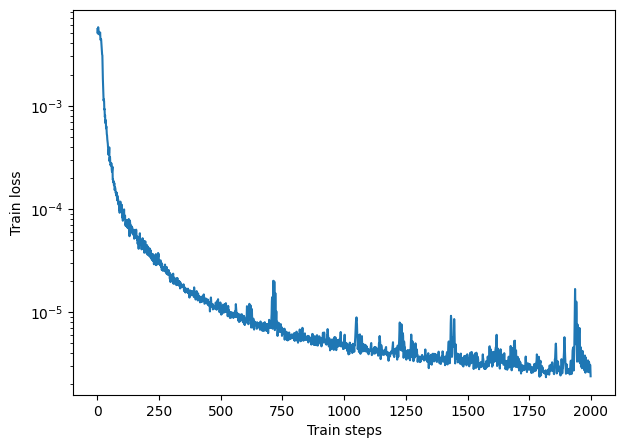

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Train steps")
ax.set_ylabel("Train loss")

Text(0, 0.5, '$u_{pred}-u_{data}$')

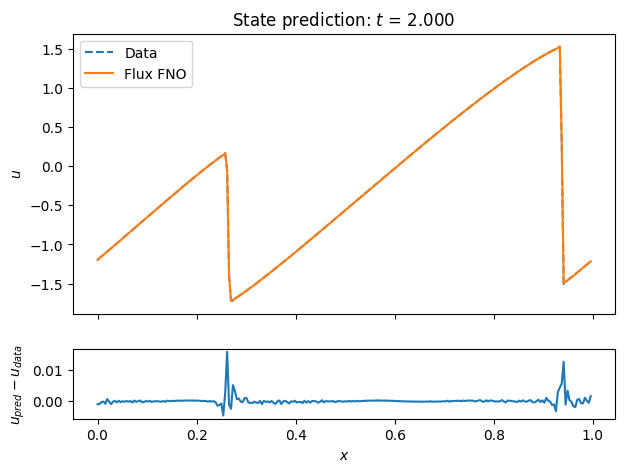

In [44]:
sample_idx = 0
time_idx = 500
u0 = batch[0][sample_idx, 0]
u1 = batch[0][sample_idx, 1]
dt = batch[1]

dx = batch[2]


fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=(4, 1))

u1_pred = model_trained(u0, dt, dx)[0]
axes[0].plot(jnp.arange(len(u1[0])) * dx, u1[0], "--", label="Data")
axes[0].plot(jnp.arange(len(u1[0])) * dx, u1_pred, label="Flux FNO")
axes[0].legend()

axes[0].set_ylabel("$u$")
axes[0].set_title(f"State prediction: $t$ = {time_idx * float(dt):3.3f}")
axes[1].plot(jnp.arange(len(u1[0])) * dx, u1_pred - u1[0])
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u_{pred}-u_{data}$")

Text(0.5, 1.0, 'Flux prediction: $t$ = 0.400')

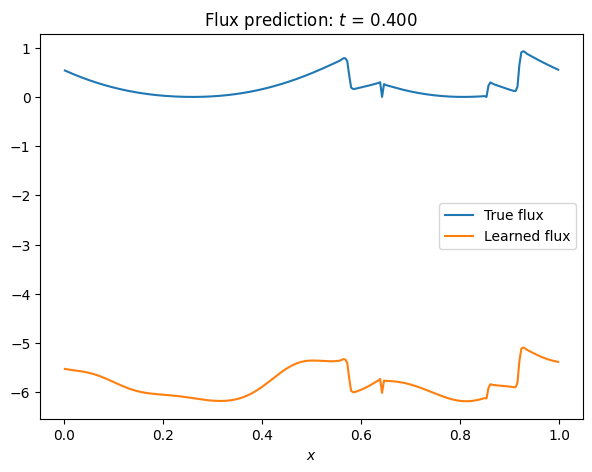

In [12]:
time_idx = 100
f_pred = model_trained.physical_flux(u0)
f_true = 0.5 * u0**2
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(x, f_true[0], label="True flux")
ax.plot(x, f_pred[0], label="Learned flux")
ax.legend()
ax.set_xlabel("$x$")
ax.set_title(f"Flux prediction: $t$ = {time_idx * float(dt):3.3f}")